# dz_rescaling 官方数据验证

对照三条结果：

1. **原方法**（Iris Cube / Improver CLI）
2. **修改后方法**（meb 站点表 / 本仓库 CLI `process`）
3. **KGO**

验收参数与上游 acceptance 一致：Estimate `forecast_period=6`，`dz∈[-550,550]`，`land_constraint=True`；Apply 默认 `frt_hour_leniency=1`。

## 环境准备

In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import iris
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from meteva_base import write_stadata_to_csv
from meteva_base.basicdata.sta_data import set_stadata_attrs, sta_data

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")
warnings.filterwarnings("ignore", message="ERROR in stadata dtype convert")

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PACKAGE_ROOT = Path.cwd().resolve().parents[0]
PROJECT_ROOT = PACKAGE_ROOT.parent
IMPROVER_ROOT = PROJECT_ROOT / "improver-1.18.7"
DATA_DIR = PACKAGE_ROOT / "test_data"
EST_DIR = DATA_DIR / "estimate-dz-rescaling"
APP_DIR = DATA_DIR / "apply-dz-rescaling"
EST_CLI_INPUT_DIR = EST_DIR / "cli_input"
EST_CLI_OUTPUT_DIR = EST_DIR / "cli_output"
APP_CLI_INPUT_DIR = APP_DIR / "cli_input"
APP_CLI_OUTPUT_DIR = APP_DIR / "cli_output"
for _d in (
    EST_CLI_INPUT_DIR,
    EST_CLI_OUTPUT_DIR,
    APP_CLI_INPUT_DIR,
    APP_CLI_OUTPUT_DIR,
):
    _d.mkdir(parents=True, exist_ok=True)

for path in (str(PROJECT_ROOT), str(IMPROVER_ROOT)):
    if path not in sys.path:
        sys.path.insert(0, path)

# 导入原方法并在notebook中调用
from improver import cli as improver_cli  # pyright: ignore[reportMissingImports]
from improver.calibration.dz_rescaling import (  # pyright: ignore[reportMissingImports]
    ApplyDzRescaling as OrigApplyDzRescaling,
    EstimateDzRescaling as OrigEstimateDzRescaling,
)
from dz_rescaling import ApplyDzRescaling, EstimateDzRescaling
from dz_rescaling.cli.dsc_apply_dz_rescaling import process as apply_cli_process
from dz_rescaling.cli.dsc_estimate_dz_rescaling import process as estimate_cli_process

SECONDS_IN_HOUR = 3600
print("包目录:", PACKAGE_ROOT)
print("Estimate 数据:", EST_DIR)
print("Apply 数据:", APP_DIR)

d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


包目录: D:\workspace\improver\dz_rescaling
Estimate 数据: D:\workspace\improver\dz_rescaling\test_data\estimate-dz-rescaling
Apply 数据: D:\workspace\improver\dz_rescaling\test_data\apply-dz-rescaling


## 公共工具函数

In [2]:
def cube_data_1d(cube_slice):
    """将 mask 数组转为 float，缺测为 nan。"""
    arr = cube_slice.data
    if np.ma.isMaskedArray(arr):
        return np.ma.filled(arr.astype(float), np.nan).reshape(-1)
    return np.asarray(arr, dtype=float).reshape(-1)


def forecast_cube_to_sta(cube, data_name="wind_speed"):
    wmo = cube.coord("wmo_id").points.astype(str)
    lon = cube.coord("longitude").points.astype(float)
    lat = cube.coord("latitude").points.astype(float)
    rows = []
    dim_names = [c.name() for c in cube.coords(dim_coords=True)]
    frt_slices = (
        list(cube.slices_over("forecast_reference_time"))
        if "forecast_reference_time" in dim_names
        else [cube]
    )
    for frt_sl in frt_slices:
        frt = pd.Timestamp(str(frt_sl.coord("forecast_reference_time").cell(0).point))
        dim2 = [c.name() for c in frt_sl.coords(dim_coords=True)]
        fp_slices = (
            list(frt_sl.slices_over("forecast_period"))
            if "forecast_period" in dim2
            else [frt_sl]
        )
        for fp_sl in fp_slices:
            fp_h = float(fp_sl.coord("forecast_period").points[0]) / SECONDS_IN_HOUR
            data = cube_data_1d(fp_sl)
            perc = (
                float(fp_sl.coord("percentile").points[0])
                if fp_sl.coords("percentile")
                else None
            )
            if data.size != len(wmo):
                raise ValueError(f"预报长度 {data.size} 与站点数 {len(wmo)} 不一致")
            for i, site_id in enumerate(wmo):
                row = {
                    "level": 0,
                    "time": frt,
                    "dtime": fp_h,
                    "id": site_id,
                    "lon": lon[i],
                    "lat": lat[i],
                    data_name: float(data[i]),
                }
                if perc is not None:
                    row["percentile"] = perc
                rows.append(row)
    return pd.DataFrame(rows)


def truth_cube_to_sta(cube, data_name="wind_speed"):
    """实况：time=有效时间，dtime=0。"""
    wmo = cube.coord("wmo_id").points.astype(str)
    lon = cube.coord("longitude").points.astype(float)
    lat = cube.coord("latitude").points.astype(float)
    rows = []
    for t_sl in cube.slices_over("time"):
        valid_time = pd.Timestamp(str(t_sl.coord("time").cell(0).point))
        vals = cube_data_1d(t_sl)
        for i, site_id in enumerate(wmo):
            rows.append(
                {
                    "level": 0,
                    "time": valid_time,
                    "dtime": 0,
                    "id": site_id,
                    "lon": lon[i],
                    "lat": lat[i],
                    data_name: float(vals[i]),
                }
            )
    return pd.DataFrame(rows)


def neighbour_cube_to_sta(cube):
    wmo = cube.coord("wmo_id").points.astype(str)
    lon = cube.coord("longitude").points.astype(float)
    lat = cube.coord("latitude").points.astype(float)
    methods = cube.coord("neighbour_selection_method_name").points
    keys = list(cube.coord("grid_attributes_key").points)
    v_idx = keys.index("vertical_displacement")
    rows = []
    for method_i, method in enumerate(methods):
        dz = np.asarray(cube.data[method_i, v_idx, :], dtype=float)
        for i, site_id in enumerate(wmo):
            rows.append(
                {
                    "level": 0,
                    "time": pd.Timestamp("2000-01-01"),
                    "dtime": 0,
                    "id": site_id,
                    "lon": lon[i],
                    "lat": lat[i],
                    "neighbour_selection_method": str(method),
                    "vertical_displacement": float(dz[i]),
                }
            )
    return pd.DataFrame(rows)


def scaled_cube_to_sta(cube):
    wmo = cube.coord("wmo_id").points.astype(str)
    lon = cube.coord("longitude").points.astype(float)
    lat = cube.coord("latitude").points.astype(float)
    fp_h = float(cube.coord("forecast_period").points[0]) / SECONDS_IN_HOUR
    dim_names = [c.name() for c in cube.coords(dim_coords=True)]
    hour_slices = (
        list(cube.slices_over("forecast_reference_time_hour"))
        if "forecast_reference_time_hour" in dim_names
        else [cube]
    )
    rows = []
    for h_sl in hour_slices:
        hour = int(
            h_sl.coord("forecast_reference_time_hour").points[0] // SECONDS_IN_HOUR
        )
        vals = cube_data_1d(h_sl)
        for i, site_id in enumerate(wmo):
            rows.append(
                {
                    "level": 0,
                    "time": pd.Timestamp("2000-01-01"),
                    "dtime": fp_h,
                    "id": site_id,
                    "lon": lon[i],
                    "lat": lat[i],
                    "forecast_reference_time_hour": hour,
                    "scaled_vertical_displacement": float(vals[i]),
                }
            )
    return pd.DataFrame(rows)


def normalize_ids(values):
    out = []
    for value in values:
        text = str(value)
        out.append(int(text) if text.isdigit() else text)
    return out


def series_from_spot_cube(cube, data=None):
    values = cube.data if data is None else data
    return pd.Series(
        np.asarray(values, dtype=float).reshape(-1),
        index=normalize_ids(cube.coord("wmo_id").points.astype(str)),
        name=cube.name(),
    )


def series_from_sta(df, value_col, id_col="id"):
    tmp = df.assign(**{id_col: normalize_ids(df[id_col])}).drop_duplicates(
        id_col, keep="first"
    )
    return tmp.set_index(id_col)[value_col].astype(float)


def compare_series(left, right, title, atol=1e-4, rtol=1e-4):
    common = left.index.intersection(right.index)
    left_c = left.loc[common].astype(float)
    right_c = right.loc[common].astype(float)
    diff = (left_c - right_c).abs()
    ok = np.allclose(left_c, right_c, atol=atol, rtol=rtol, equal_nan=True)
    print(
        f"{title}: n={len(common)} allclose={ok} "
        f"maxabs={float(np.nanmax(diff.to_numpy())):.6g} "
        f"meanabs={float(np.nanmean(diff.to_numpy())):.6g}"
    )
    return ok, common, diff


def inherit_sta_attrs_from_cube(sta, cube=None, *, units=None, model_var=None):
    """从 Iris Cube 继承可映射的 meb 属性；缺省则保留/补默认值。"""
    if units is None:
        units = str(cube.units) if cube is not None else ""
    if model_var is None:
        model_var = cube.name() if cube is not None else ""
    set_stadata_attrs(
        sta,
        units=units,
        model_var=model_var,
        dtime_units="hour",
        level_type="isobaric",
        time_type="UT",
        time_bounds=[0, 0],
    )
    return sta


def ensure_path_removed(*paths):
    """删除已存在路径（及 Improver 写盘用的 .tmp），避免 Windows 上 rename 失败。"""
    for path in paths:
        path = Path(path)
        for candidate in (path, Path(str(path) + ".tmp")):
            if candidate.exists():
                candidate.unlink()


def plot_input_maps(panels, title):
    """panels: list[(title, lon, lat, values, cmap)]"""
    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4), squeeze=False)
    for ax, (ptitle, lon, lat, vals, cmap) in zip(axes[0], panels):
        sc = ax.scatter(lon, lat, c=vals, s=12, cmap=cmap)
        ax.set_title(ptitle)
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        ax.grid(True, alpha=0.3)
        fig.colorbar(sc, ax=ax, fraction=0.046)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_three_results(loc_df, orig_s, mig_s, kgo_s, title, value_label):
    """三图对比：修改后方法 / 原方法 / KGO（空间散点，统一色标）。"""
    loc = loc_df.assign(id=normalize_ids(loc_df["id"])).drop_duplicates(
        "id", keep="first"
    )
    common = (
        set(loc["id"])
        & set(orig_s.index)
        & set(mig_s.index)
        & set(kgo_s.index)
    )
    loc = loc[loc["id"].isin(common)].set_index("id")
    common_idx = loc.index
    panels = [
        ("修改后方法", mig_s.loc[common_idx].astype(float)),
        ("原方法", orig_s.loc[common_idx].astype(float)),
        ("KGO", kgo_s.loc[common_idx].astype(float)),
    ]
    vals = np.concatenate([p[1].to_numpy() for p in panels])
    vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
    for ax, (name, series) in zip(axes, panels):
        sc = ax.scatter(
            loc.loc[series.index, "lon"],
            loc.loc[series.index, "lat"],
            c=series.to_numpy(),
            s=12,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(name)
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        # sharey 默认只在左图显示 lat 刻度，这里强制三图都显示
        ax.tick_params(axis="y", labelleft=True)
        ax.grid(True, alpha=0.3)
        fig.colorbar(sc, ax=ax, fraction=0.046, label=value_label)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


print("工具函数已定义")

工具函数已定义


## 1. EstimateDzRescaling

### 1.1 输入预处理

In [3]:
estimate_cases = [
    {
        "tag": "T1200Z",
        "forecast": "T1200Z-PT0006H00M-wind_speed_at_10m.nc",
        "truth": "T1200Z-srfc_wind_sped_spot_truths.nc",
        "kgo": "T1200Z_kgo.nc",
    },
    {
        "tag": "T1500Z",
        "forecast": "T1500Z-PT0132H00M-wind_speed_at_10m.nc",
        "truth": "T1500Z-srfc_wind_sped_spot_truths.nc",
        "kgo": "T1500Z_kgo.nc",
    },
]

neighbour_cube = iris.load_cube(str(EST_DIR / "neighbour.nc"))
neighbour_sta = sta_data(neighbour_cube_to_sta(neighbour_cube))
neighbour_sta = inherit_sta_attrs_from_cube(neighbour_sta, neighbour_cube)
write_stadata_to_csv(
    neighbour_sta, str(EST_CLI_INPUT_DIR / "neighbour.csv"), effective_num=8, creat_dir=True
)

estimate_inputs = {}
for case in estimate_cases:
    tag = case["tag"]
    forecast_cube = iris.load_cube(str(EST_DIR / case["forecast"]))
    truth_cube = iris.load_cube(str(EST_DIR / case["truth"]))
    kgo_cube = iris.load_cube(str(EST_DIR / case["kgo"]))

    forecast_sta = sta_data(forecast_cube_to_sta(forecast_cube))
    truth_sta = sta_data(truth_cube_to_sta(truth_cube))
    forecast_sta = inherit_sta_attrs_from_cube(forecast_sta, forecast_cube)
    truth_sta = inherit_sta_attrs_from_cube(truth_sta, truth_cube)
    write_stadata_to_csv(
        forecast_sta,
        str(EST_CLI_INPUT_DIR / f"{tag}_forecast.csv"),
        effective_num=8,
        creat_dir=True,
    )
    write_stadata_to_csv(
        truth_sta,
        str(EST_CLI_INPUT_DIR / f"{tag}_truth.csv"),
        effective_num=8,
        creat_dir=True,
    )

    estimate_inputs[tag] = {
        "forecast_cube": forecast_cube,
        "truth_cube": truth_cube,
        "kgo_cube": kgo_cube,
        "forecast_sta": forecast_sta,
        "truth_sta": truth_sta,
    }
    print(tag, "预报/实况:", forecast_sta.shape, truth_sta.shape)

print("neighbour:", neighbour_sta.shape)
print("已写入:", EST_CLI_INPUT_DIR)

ERROR in stadata dtype convert!
could not convert string to float: 'nearest'
T1200Z 预报/实况: (3702, 8) (3165, 7)
T1500Z 预报/实况: (14808, 8) (3141, 7)
neighbour: (4936, 8)
已写入: D:\workspace\improver\dz_rescaling\test_data\estimate-dz-rescaling\cli_input


### 1.2 输入数据图

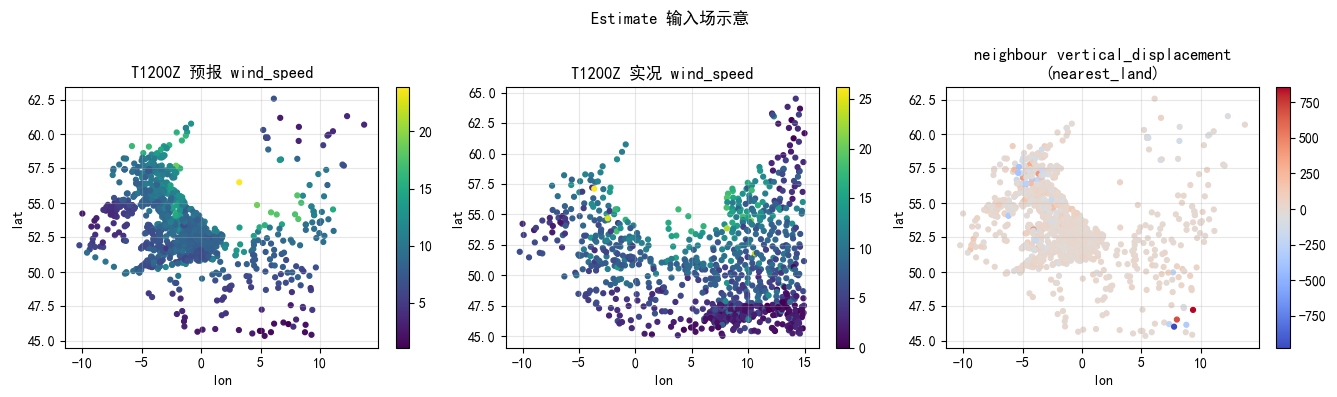

In [4]:
tag0 = estimate_cases[0]["tag"]
fc0 = estimate_inputs[tag0]["forecast_sta"].drop_duplicates("id", keep="first")
tr0 = estimate_inputs[tag0]["truth_sta"].drop_duplicates("id", keep="first")
dz_land = neighbour_sta.loc[
    neighbour_sta["neighbour_selection_method"] == "nearest_land"
].drop_duplicates("id", keep="first")

plot_input_maps(
    [
        (f"{tag0} 预报 wind_speed", fc0["lon"], fc0["lat"], fc0["wind_speed"], "viridis"),
        (f"{tag0} 实况 wind_speed", tr0["lon"], tr0["lat"], tr0["wind_speed"], "viridis"),
        (
            "neighbour vertical_displacement\n(nearest_land)",
            dz_land["lon"],
            dz_land["lat"],
            dz_land["vertical_displacement"],
            "coolwarm",
        ),
    ],
    "Estimate 输入场示意",
)

### 1.3 方法调用（修改后方法 / 原方法）

In [5]:
estimate_results = {}

for case in estimate_cases:
    tag = case["tag"]
    item = estimate_inputs[tag]

    # 原方法调用
    orig = OrigEstimateDzRescaling(
        forecast_period=6,
        dz_lower_bound=-550,
        dz_upper_bound=550,
        land_constraint=True,
    )(item["forecast_cube"], item["truth_cube"], neighbour_cube)
    # 修改后方法调用
    migrated = EstimateDzRescaling(
        forecast_period=6,
        forecast_data_name="wind_speed",
        dz_lower_bound=-550,
        dz_upper_bound=550,
        land_constraint=True,
    )(item["forecast_sta"], item["truth_sta"], neighbour_sta)

    orig_s = series_from_spot_cube(orig)
    kgo_s = series_from_spot_cube(item["kgo_cube"])
    mig_s = series_from_sta(migrated, "scaled_vertical_displacement")

    print("====", tag, "====")
    ok1, _, _ = compare_series(orig_s, kgo_s, "原方法 ~ KGO")
    ok2, _, _ = compare_series(mig_s, kgo_s, "修改后方法 ~ KGO")
    ok3, _, _ = compare_series(mig_s, orig_s, "修改后方法 ~ 原方法")
    estimate_results[tag] = {
        "ok": ok1 and ok2 and ok3,
        "orig_s": orig_s,
        "mig_s": mig_s,
        "kgo_s": kgo_s,
        "migrated": migrated,
    }

assert all(v["ok"] for v in estimate_results.values()), "Estimate 对照未全部通过"
print("\nEstimate 全部用例通过")

==== T1200Z ====
原方法 ~ KGO: n=1234 allclose=True maxabs=2.98023e-08 meanabs=2.4151e-11
修改后方法 ~ KGO: n=1234 allclose=True maxabs=2.38419e-07 meanabs=2.97299e-08
修改后方法 ~ 原方法: n=1234 allclose=True maxabs=2.38419e-07 meanabs=2.97057e-08
==== T1500Z ====
原方法 ~ KGO: n=1234 allclose=True maxabs=1.19209e-07 meanabs=2.4151e-10
修改后方法 ~ KGO: n=1234 allclose=True maxabs=1.19209e-07 meanabs=3.09133e-08
修改后方法 ~ 原方法: n=1234 allclose=True maxabs=1.19209e-07 meanabs=3.11548e-08

Estimate 全部用例通过


### 1.4 结果图对比（修改后方法 / 原方法 / KGO）

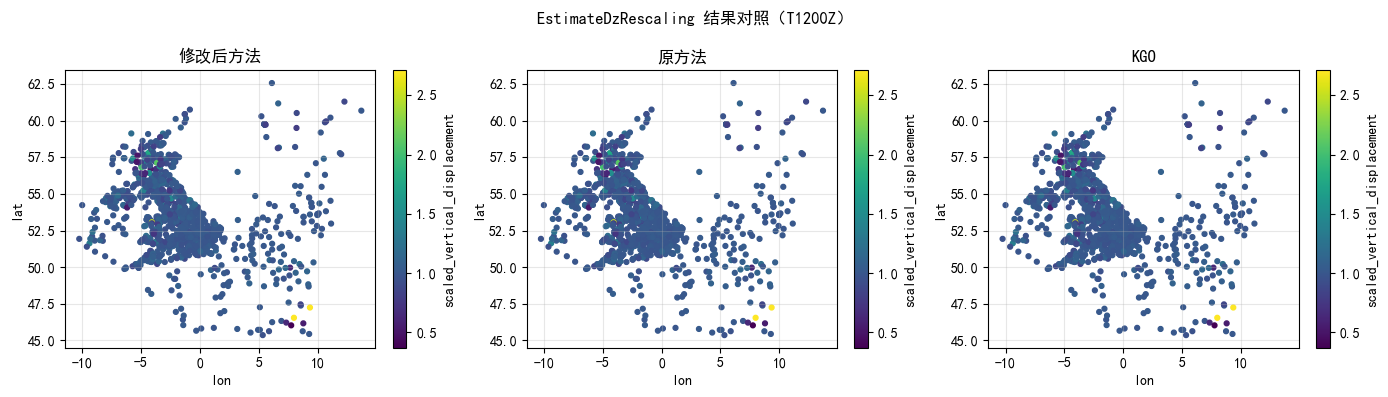

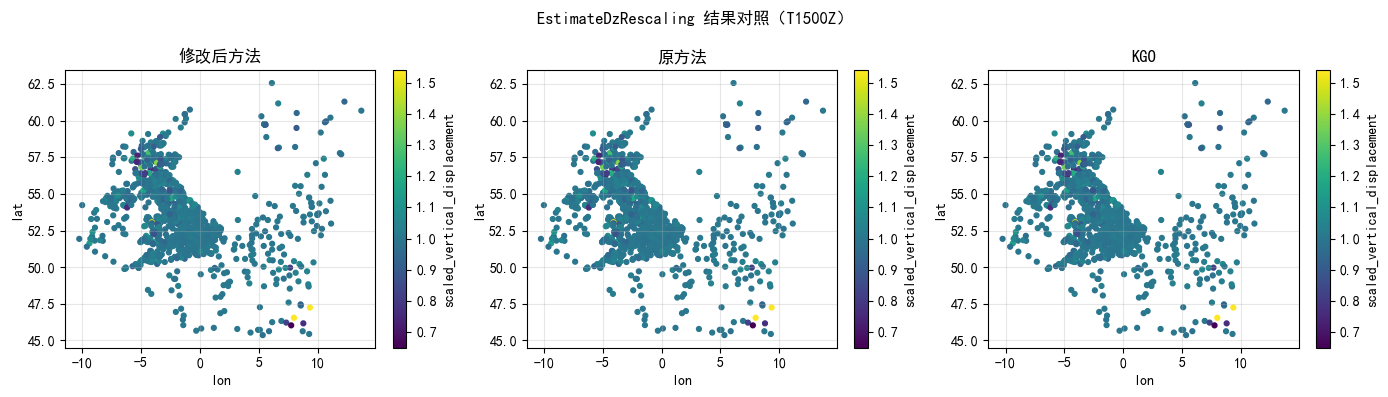

In [6]:
for case in estimate_cases:
    tag = case["tag"]
    item = estimate_results[tag]
    plot_three_results(
        item["migrated"][["id", "lon", "lat"]],
        item["orig_s"],
        item["mig_s"],
        item["kgo_s"],
        title=f"EstimateDzRescaling 结果对照（{tag}）",
        value_label="scaled_vertical_displacement",
    )

## 2. ApplyDzRescaling

### 2.1 输入预处理

In [7]:
apply_forecast_cube = iris.load_cube(
    str(APP_DIR / "20230220T1200Z-PT0006H00M-wind_speed_at_10m.nc")
)
apply_scaled_cube = iris.load_cube(str(APP_DIR / "scaled_dz.nc"))
apply_kgo_cube = iris.load_cube(str(APP_DIR / "kgo.nc"))

apply_forecast_sta = sta_data(forecast_cube_to_sta(apply_forecast_cube))
apply_scaled_sta = sta_data(scaled_cube_to_sta(apply_scaled_cube))
apply_forecast_sta = inherit_sta_attrs_from_cube(
    apply_forecast_sta, apply_forecast_cube
)
apply_scaled_sta = inherit_sta_attrs_from_cube(apply_scaled_sta, apply_scaled_cube)
write_stadata_to_csv(
    apply_forecast_sta,
    str(APP_CLI_INPUT_DIR / "apply_forecast.csv"),
    effective_num=8,
    creat_dir=True,
)
write_stadata_to_csv(
    apply_scaled_sta,
    str(APP_CLI_INPUT_DIR / "apply_scaled_dz.csv"),
    effective_num=8,
    creat_dir=True,
)

print("预报 FRT/dtime:")
print(apply_forecast_sta[["time", "dtime"]].drop_duplicates())
print("scaled_dz 起报小时:", sorted(apply_scaled_sta["forecast_reference_time_hour"].unique()))
print("已写入:", APP_CLI_INPUT_DIR)

预报 FRT/dtime:
                 time  dtime
0 2023-02-20 06:00:00      6
scaled_dz 起报小时: [np.float32(3.0), np.float32(6.0)]
已写入: D:\workspace\improver\dz_rescaling\test_data\apply-dz-rescaling\cli_input


### 2.2 输入数据图

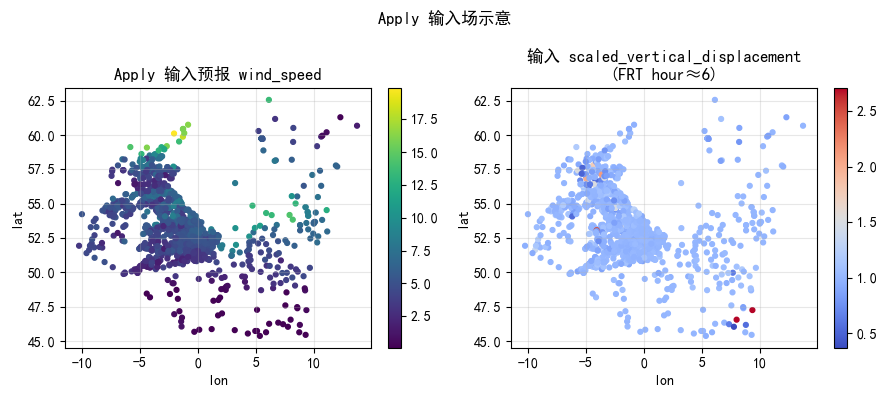

In [8]:
fc_plot = apply_forecast_sta.drop_duplicates("id", keep="first")
fc_hour = int(pd.to_datetime(fc_plot["time"].iloc[0]).hour)
sd = apply_scaled_sta.copy()
sd["hour24"] = sd["forecast_reference_time_hour"].astype(int) % 24
sd_plot = sd.loc[sd["hour24"] == fc_hour].drop_duplicates("id", keep="first")
if sd_plot.empty:
    sd_plot = sd.drop_duplicates("id", keep="first")

plot_input_maps(
    [
        ("Apply 输入预报 wind_speed", fc_plot["lon"], fc_plot["lat"], fc_plot["wind_speed"], "viridis"),
        (
            f"输入 scaled_vertical_displacement\n(FRT hour≈{fc_hour})",
            sd_plot["lon"],
            sd_plot["lat"],
            sd_plot["scaled_vertical_displacement"],
            "coolwarm",
        ),
    ],
    "Apply 输入场示意",
)

### 2.3 方法调用（修改后方法 / 原方法）

In [9]:
# 原方法调用
apply_orig = OrigApplyDzRescaling()(
    apply_forecast_cube.copy(), apply_scaled_cube
)
# 修改后方法调用
apply_migrated = ApplyDzRescaling(
    frt_hour_leniency=1,
    forecast_data_name="wind_speed",
)(apply_forecast_sta, apply_scaled_sta)

apply_orig_s = series_from_spot_cube(apply_orig)
apply_kgo_s = series_from_spot_cube(apply_kgo_cube)
apply_mig_s = series_from_sta(apply_migrated, "wind_speed")

ok1, _, _ = compare_series(apply_orig_s, apply_kgo_s, "原方法 ~ KGO")
ok2, _, _ = compare_series(apply_mig_s, apply_kgo_s, "修改后方法 ~ KGO")
ok3, _, _ = compare_series(apply_mig_s, apply_orig_s, "修改后方法 ~ 原方法")
assert ok1 and ok2 and ok3, "Apply 对照未通过"
print("\nApply 对照通过")

原方法 ~ KGO: n=1234 allclose=True maxabs=0 meanabs=0
修改后方法 ~ KGO: n=1234 allclose=True maxabs=0 meanabs=0
修改后方法 ~ 原方法: n=1234 allclose=True maxabs=0 meanabs=0

Apply 对照通过


### 2.4 结果图对比（修改后方法 / 原方法 / KGO）

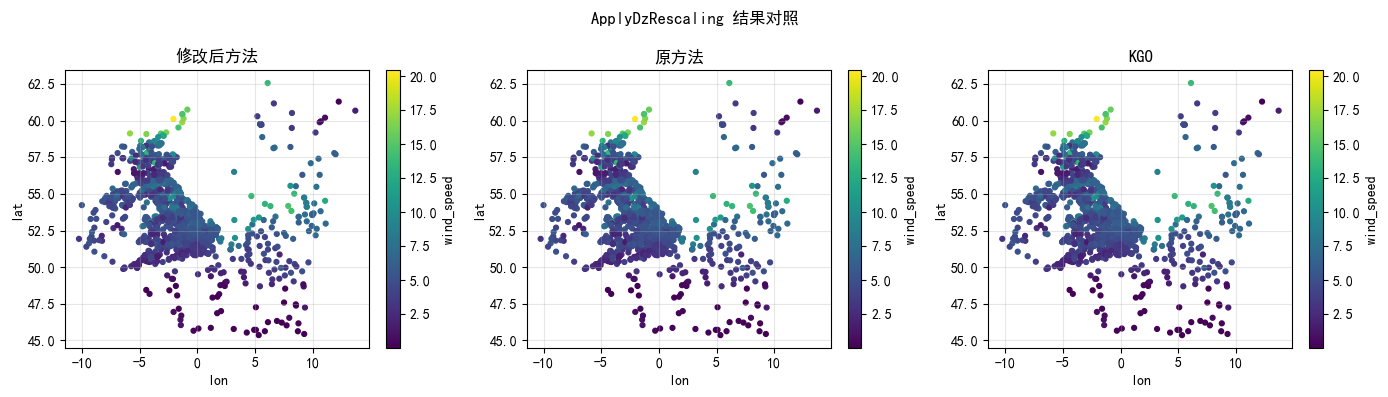

In [10]:
plot_three_results(
    apply_migrated[["id", "lon", "lat"]],
    apply_orig_s,
    apply_mig_s,
    apply_kgo_s,
    title="ApplyDzRescaling 结果对照",
    value_label="wind_speed",
)

## 3. CLI 示例

- **修改后 CLI**：调用本仓库 `dsc_*` 脚本中的 `process`，读写 `cli_input` / `cli_output`
- **原方法 CLI**：通过 Improver `cli.main` 调用 `estimate-dz-rescaling` / `apply-dz-rescaling`，处理官方 NetCDF
- 再与 KGO 做三图对比

### 3.1 Estimate CLI

attrs,values

{'units': 'm s-1', 'model_var': '', 'dtime_units': 'hour', 'level_type': 'isobaric', 'time_type': 'UT', 'time_bounds': '[0, 0]'}
attrs,values

{'units': 'm/s', 'model_var': '', 'dtime_units': 'hour', 'level_type': 'isobaric', 'time_type': 'UT', 'time_bounds': '[0, 0]'}
attrs,values

{'units': '1', 'model_var': '', 'dtime_units': 'hour', 'level_type': 'isobaric', 'time_type': 'UT', 'time_bounds': '[0, 0]'}
ERROR in stadata dtype convert!
could not convert string to float: 'nearest'
修改后 Estimate CLI 输出: D:\workspace\improver\dz_rescaling\test_data\estimate-dz-rescaling\cli_output\scaled_vertical_displacement_T1200Z.csv (1234, 8)
Run-time: 1.1676523999776691s; improver estimate-dz-rescaling 'D:\workspace\improver\dz_rescaling\test_data\estimate-dz-rescaling\T1200Z-PT0006H00M-wind_speed_at_10m.nc' 'D:\workspace\improver\dz_rescaling\test_data\estimate-dz-rescaling\T1200Z-srfc_wind_sped_spot_truths.nc' 'D:\workspace\improver\dz_rescaling\test_data\estimate-dz-rescaling\neighbo

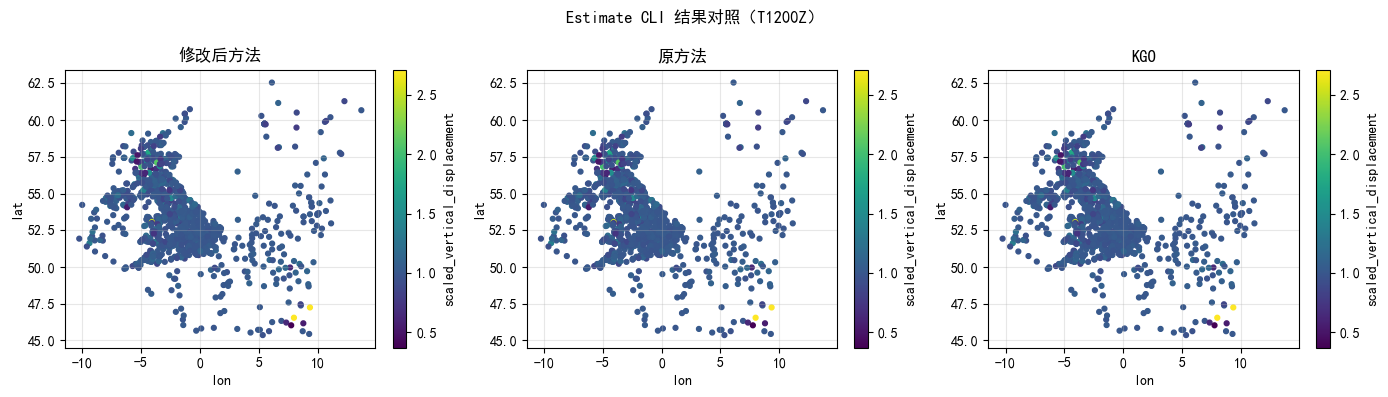

In [11]:
# 修改后 CLI：process(cli_input) -> cli_output
est_cli_out = EST_CLI_OUTPUT_DIR / "scaled_vertical_displacement_T1200Z.csv"
est_cli_mig = estimate_cli_process(
    EST_CLI_INPUT_DIR / "T1200Z_forecast.csv",
    EST_CLI_INPUT_DIR / "T1200Z_truth.csv",
    EST_CLI_INPUT_DIR / "neighbour.csv",
    forecast_period=6,
    forecast_data_name="wind_speed",
    dz_lower_bound=-550,
    dz_upper_bound=550,
    land_constraint=True,
    output_path=est_cli_out,
)
print("修改后 Estimate CLI 输出:", est_cli_out, est_cli_mig.shape)

# 原方法 CLI：improver estimate-dz-rescaling
est_cli_orig_nc = EST_CLI_OUTPUT_DIR / "orig_estimate_T1200Z.nc"
ensure_path_removed(est_cli_orig_nc)
improver_cli.main(
    "improver",
    "estimate-dz-rescaling",
    str(EST_DIR / "T1200Z-PT0006H00M-wind_speed_at_10m.nc"),
    str(EST_DIR / "T1200Z-srfc_wind_sped_spot_truths.nc"),
    str(EST_DIR / "neighbour.nc"),
    "--forecast-period",
    "6",
    "--dz-lower-bound",
    "-550",
    "--dz-upper-bound",
    "550",
    "--land-constraint",
    "--output",
    str(est_cli_orig_nc),
    verbose=True,
)
est_cli_orig_cube = iris.load_cube(str(est_cli_orig_nc))
print("原方法 Estimate CLI 输出:", est_cli_orig_nc)

est_cli_mig_s = series_from_sta(est_cli_mig, "scaled_vertical_displacement")
est_cli_orig_s = series_from_spot_cube(est_cli_orig_cube)
est_cli_kgo_s = series_from_spot_cube(estimate_inputs["T1200Z"]["kgo_cube"])

ok1, _, _ = compare_series(est_cli_orig_s, est_cli_kgo_s, "原 CLI ~ KGO")
ok2, _, _ = compare_series(est_cli_mig_s, est_cli_kgo_s, "修改后 CLI ~ KGO")
ok3, _, _ = compare_series(est_cli_mig_s, est_cli_orig_s, "修改后 CLI ~ 原 CLI")
assert ok1 and ok2 and ok3, "Estimate CLI 对照未通过"
print("Estimate CLI 对照通过")

plot_three_results(
    est_cli_mig[["id", "lon", "lat"]],
    est_cli_orig_s,
    est_cli_mig_s,
    est_cli_kgo_s,
    title="Estimate CLI 结果对照（T1200Z）",
    value_label="scaled_vertical_displacement",
)

### 3.2 Apply CLI

attrs,values

{'units': 'm s-1', 'model_var': '', 'dtime_units': 'hour', 'level_type': 'isobaric', 'time_type': 'UT', 'time_bounds': '[0, 0]'}
attrs,values

{'units': '1', 'model_var': '', 'dtime_units': 'hour', 'level_type': 'isobaric', 'time_type': 'UT', 'time_bounds': '[0, 0]'}
修改后 Apply CLI 输出: D:\workspace\improver\dz_rescaling\test_data\apply-dz-rescaling\cli_output\forecast_rescaled.csv (1234, 8)
Run-time: 0.06156680011190474s; improver apply-dz-rescaling 'D:\workspace\improver\dz_rescaling\test_data\apply-dz-rescaling\20230220T1200Z-PT0006H00M-wind_speed_at_10m.nc' 'D:\workspace\improver\dz_rescaling\test_data\apply-dz-rescaling\scaled_dz.nc' --output 'D:\workspace\improver\dz_rescaling\test_data\apply-dz-rescaling\cli_output\orig_apply_rescaled.nc'
原方法 Apply CLI 输出: D:\workspace\improver\dz_rescaling\test_data\apply-dz-rescaling\cli_output\orig_apply_rescaled.nc
原 CLI ~ KGO: n=1234 allclose=True maxabs=0 meanabs=0
修改后 CLI ~ KGO: n=1234 allclose=True maxabs=0 meanabs=0
修改后 CLI 

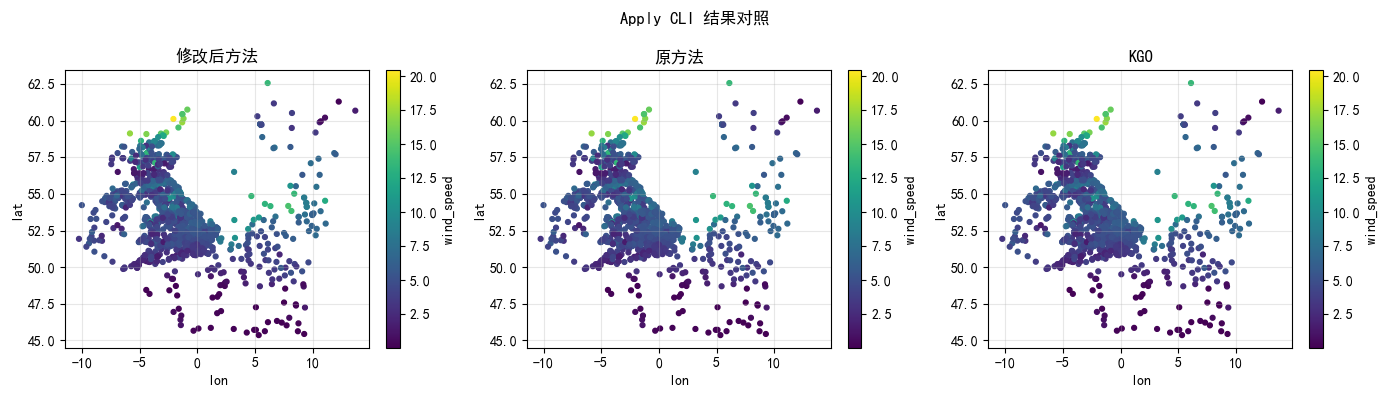

In [12]:
# 修改后 CLI
app_cli_out = APP_CLI_OUTPUT_DIR / "forecast_rescaled.csv"
app_cli_mig = apply_cli_process(
    APP_CLI_INPUT_DIR / "apply_forecast.csv",
    APP_CLI_INPUT_DIR / "apply_scaled_dz.csv",
    forecast_data_name="wind_speed",
    output_path=app_cli_out,
    frt_hour_leniency=1,
)
print("修改后 Apply CLI 输出:", app_cli_out, app_cli_mig.shape)

# 原方法 CLI：improver apply-dz-rescaling
app_cli_orig_nc = APP_CLI_OUTPUT_DIR / "orig_apply_rescaled.nc"
ensure_path_removed(app_cli_orig_nc)
improver_cli.main(
    "improver",
    "apply-dz-rescaling",
    str(APP_DIR / "20230220T1200Z-PT0006H00M-wind_speed_at_10m.nc"),
    str(APP_DIR / "scaled_dz.nc"),
    "--output",
    str(app_cli_orig_nc),
    verbose=True,
)
app_cli_orig_cube = iris.load_cube(str(app_cli_orig_nc))
print("原方法 Apply CLI 输出:", app_cli_orig_nc)

app_cli_mig_s = series_from_sta(app_cli_mig, "wind_speed")
app_cli_orig_s = series_from_spot_cube(app_cli_orig_cube)
app_cli_kgo_s = series_from_spot_cube(apply_kgo_cube)

ok1, _, _ = compare_series(app_cli_orig_s, app_cli_kgo_s, "原 CLI ~ KGO")
ok2, _, _ = compare_series(app_cli_mig_s, app_cli_kgo_s, "修改后 CLI ~ KGO")
ok3, _, _ = compare_series(app_cli_mig_s, app_cli_orig_s, "修改后 CLI ~ 原 CLI")
assert ok1 and ok2 and ok3, "Apply CLI 对照未通过"
print("Apply CLI 对照通过")

plot_three_results(
    app_cli_mig[["id", "lon", "lat"]],
    app_cli_orig_s,
    app_cli_mig_s,
    app_cli_kgo_s,
    title="Apply CLI 结果对照",
    value_label="wind_speed",
)

## 结论

- 预处理站点表写入各用例目录下的 `cli_input/`（继承 Cube 的 units/要素名等可映射属性，并以 `write_stadata_to_csv` 写出 attrs 头）；CLI 结果写入对应 `cli_output/`。
- API 路径与 CLI 路径均与原方法、KGO 在 `atol=rtol=1e-4` 下一致。
- 结果图为修改后方法 / 原方法 / KGO 三图空间对比（统一色标）。